# Convolutional Neural Networks: Image Classification using CIFAR-10

This notebook demonstrates how Convolutional Neural Networks (CNNs) can be used to perform image classification.

We compare three different models:
1. Baseline CNN
2. Improved CNN (deeper architecture)
3. Regularized CNN (Batch Normalization + Dropout)

The goal is to understand how architectural improvements and regularization techniques impact model performance.

In [1]:
# Import Required Libraries


import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns

np.random.seed(42)
tf.random.set_seed(42)

sns.set_palette("colorblind")

print("Libraries loaded successfully.")

Libraries loaded successfully.


### Load data

In [2]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['Airplane', 'Automobile', 'Bird', 'Cat', 'Deer',
               'Dog', 'Frog', 'Horse', 'Ship', 'Truck']

print("Training shape:", X_train.shape)
print("Test shape:", X_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Training shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


### Preprocessing

In [3]:
X_train = X_train / 255.0
X_test = X_test / 255.0

y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

print("Preprocessing complete.")

Preprocessing complete.


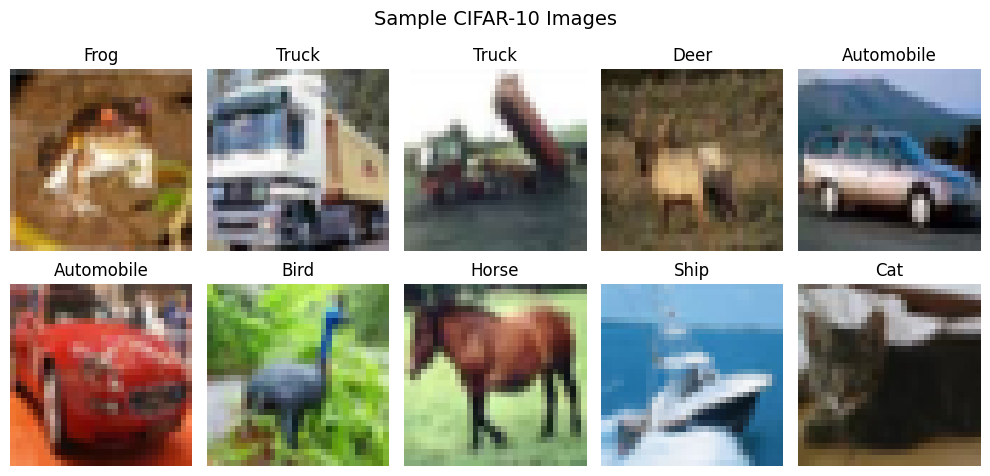

In [4]:
plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis('off')

plt.suptitle("Sample CIFAR-10 Images", fontsize=14)
plt.tight_layout()

plt.savefig("figure1_sample_images.png", dpi=300)
plt.show()

### Baseline Model

In [5]:
def build_baseline_model():
    model = models.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
        layers.MaxPooling2D((2,2)),
        layers.Conv2D(64, (3,3), activation='relu'),
        layers.MaxPooling2D((2,2)),
        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])

    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

baseline_model = build_baseline_model()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### Train Baseline Model

In [6]:
history_baseline = baseline_model.fit(
    X_train, y_train_cat,
    epochs=10,
    batch_size=64,
    validation_data=(X_test, y_test_cat),
    verbose=1
)

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 64s 78ms/step - accuracy: 0.4660 - loss: 1.4945 - val_accuracy: 0.5541 - val_loss: 1.2639
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 91s 90ms/step - accuracy: 0.5907 - loss: 1.1628 - val_accuracy: 0.6207 - val_loss: 1.0806
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 82s 90ms/step - accuracy: 0.6423 - loss: 1.0233 - val_accuracy: 0.6426 - val_loss: 1.0187
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 83s 92ms/step - accuracy: 0.6743 - loss: 0.9361 - val_accuracy: 0.6628 - val_loss: 0.9827
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 56s 71ms/step - accuracy: 0.6977 - loss: 0.8703 - val_accuracy: 0.6759 - val_loss: 0.9590
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 54s 69ms/step - accuracy: 0.7167 - loss: 0.8163 - val_accuracy: 0.6810 - val_loss: 0.9416
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 56s 71ms/step - accuracy: 0.7332 - loss: 0.7703 - val_accuracy: 0.6866 - val_loss: 0.9283
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 79s 68ms/step - accuracy: 0.7477 - loss: 0.7291 - 

### Improved Model

In [7]:
def build_improved_model():
    model = models.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
        layers.Conv2D(32, (3,3), activation='relu'),
        layers.MaxPooling2D((2,2)),
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.Conv2D(64, (3,3), activation='relu'),
        layers.MaxPooling2D((2,2)),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])

    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

improved_model = build_improved_model()

### Train Improved Model

In [8]:
history_improved = improved_model.fit(
    X_train, y_train_cat,
    epochs=10,
    batch_size=64,
    validation_data=(X_test, y_test_cat),
    verbose=1
)

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 188s 237ms/step - accuracy: 0.4679 - loss: 1.4731 - val_accuracy: 0.5925 - val_loss: 1.1368
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 183s 234ms/step - accuracy: 0.6387 - loss: 1.0213 - val_accuracy: 0.6805 - val_loss: 0.9123
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 181s 232ms/step - accuracy: 0.7099 - loss: 0.8340 - val_accuracy: 0.7005 - val_loss: 0.8630
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 181s 232ms/step - accuracy: 0.7496 - loss: 0.7154 - val_accuracy: 0.7228 - val_loss: 0.8209
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 184s 235ms/step - accuracy: 0.7831 - loss: 0.6252 - val_accuracy: 0.7254 - val_loss: 0.8286
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 181s 231ms/step - accuracy: 0.8068 - loss: 0.5535 - val_accuracy: 0.7233 - val_loss: 0.8710
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 181s 232ms/step - accuracy: 0.8281 - loss: 0.4935 - val_accuracy: 0.7251 - val_loss: 0.8876
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 183s 233ms/step - accuracy: 0.8447 -

### Regularized Model

In [9]:
def build_regularized_model():
    model = models.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3,3), activation='relu'),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),

        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3,3), activation='relu'),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),

        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(10, activation='softmax')
    ])

    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

regularized_model = build_regularized_model()

### Train Regularized Model

In [10]:
history_regularized = regularized_model.fit(
    X_train, y_train_cat,
    epochs=10,
    batch_size=64,
    validation_data=(X_test, y_test_cat),
    verbose=1
)

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 258s 326ms/step - accuracy: 0.2824 - loss: 1.8778 - val_accuracy: 0.3801 - val_loss: 1.6420
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 259s 322ms/step - accuracy: 0.4524 - loss: 1.4795 - val_accuracy: 0.6008 - val_loss: 1.1501
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 253s 324ms/step - accuracy: 0.5514 - loss: 1.2538 - val_accuracy: 0.6409 - val_loss: 1.0265
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 264s 327ms/step - accuracy: 0.6058 - loss: 1.1172 - val_accuracy: 0.6018 - val_loss: 1.1348
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 253s 323ms/step - accuracy: 0.6432 - loss: 1.0236 - val_accuracy: 0.6791 - val_loss: 0.9261
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 252s 322ms/step - accuracy: 0.6693 - loss: 0.9524 - val_accuracy: 0.6711 - val_loss: 0.9600
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 266s 328ms/step - accuracy: 0.6878 - loss: 0.9009 - val_accuracy: 0.7094 - val_loss: 0.8317
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 252s 322ms/step - accuracy: 0.7041 -

### Loss Plot

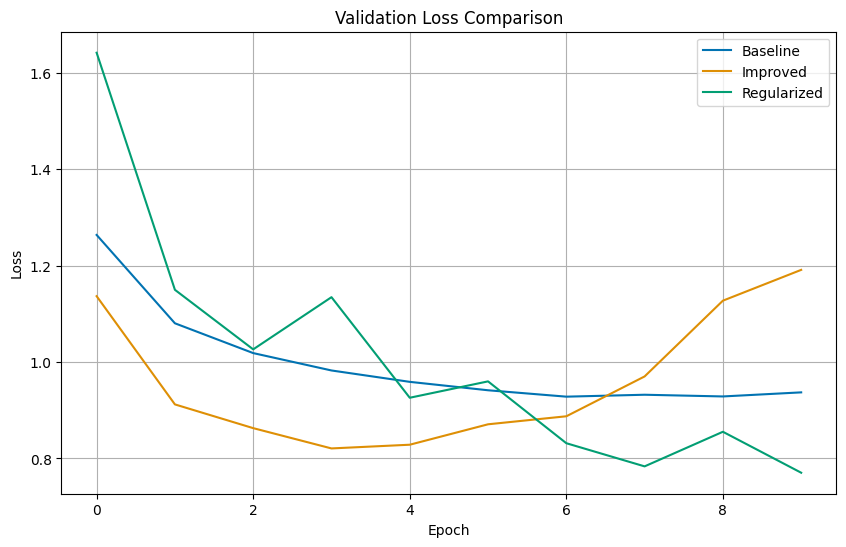

In [11]:
plt.figure(figsize=(10,6))

plt.plot(history_baseline.history['val_loss'], label='Baseline')
plt.plot(history_improved.history['val_loss'], label='Improved')
plt.plot(history_regularized.history['val_loss'], label='Regularized')

plt.title("Validation Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.savefig("figure2_loss_comparison.png", dpi=300)
plt.show()

### Accuracy Plot

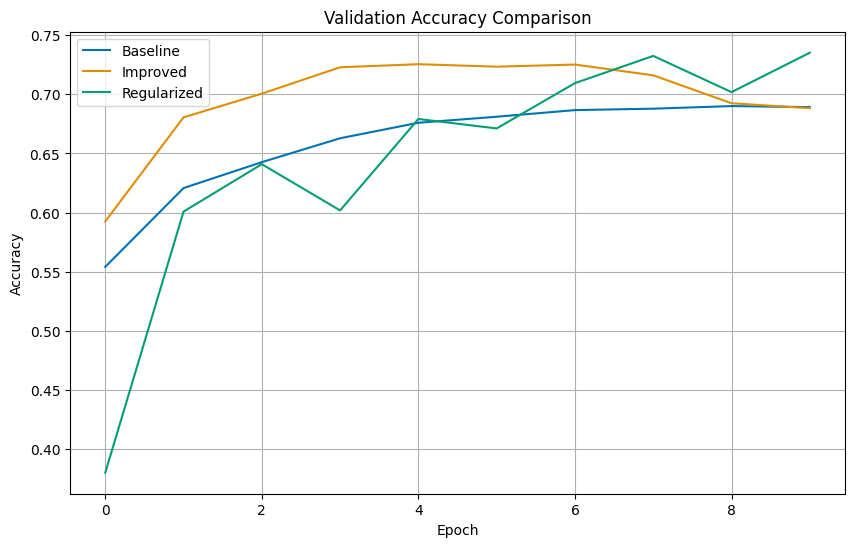

In [12]:
plt.figure(figsize=(10,6))

plt.plot(history_baseline.history['val_accuracy'], label='Baseline')
plt.plot(history_improved.history['val_accuracy'], label='Improved')
plt.plot(history_regularized.history['val_accuracy'], label='Regularized')

plt.title("Validation Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.savefig("figure3_accuracy_comparison.png", dpi=300)
plt.show()

### Confusion Matrix

313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 34ms/step


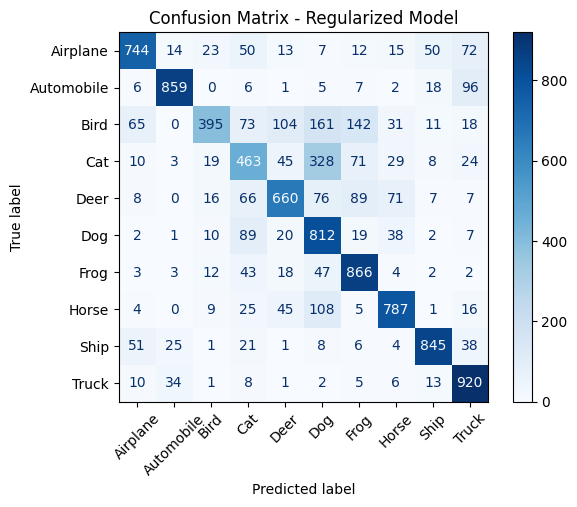

In [13]:
y_pred = regularized_model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test, y_pred_classes)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap='Blues', xticks_rotation=45)

plt.title("Confusion Matrix - Regularized Model")
plt.savefig("figure4_confusion_matrix.png", dpi=300)
plt.show()

### Sample Predictions

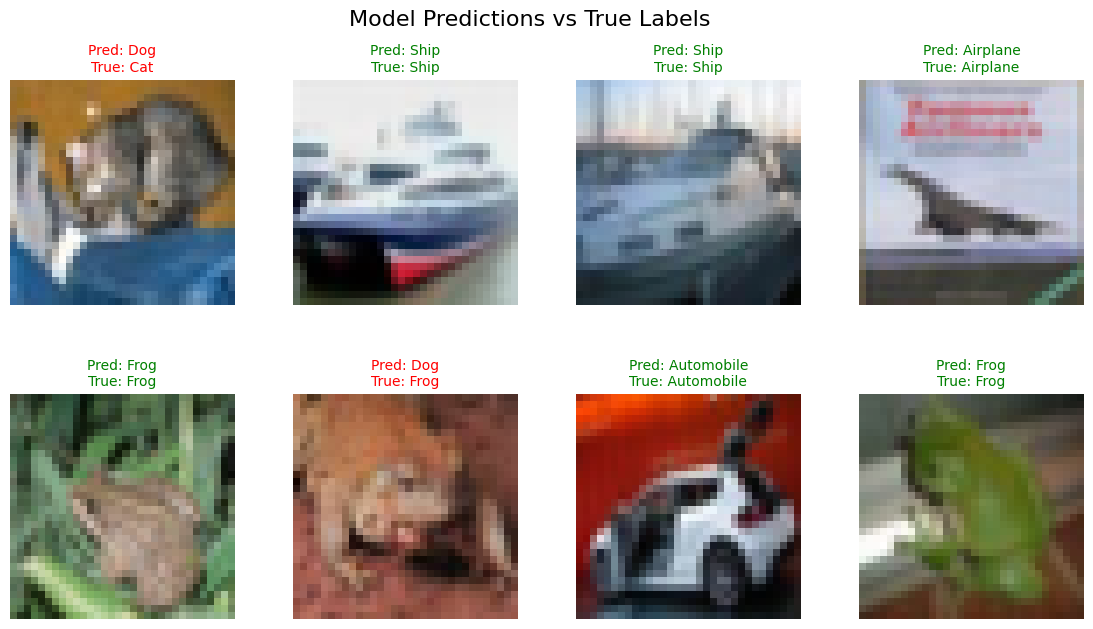

In [16]:
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
axes = axes.flatten()

for i in range(8):
    ax = axes[i]
    ax.imshow(X_test[i])

    pred = class_names[y_pred_classes[i]]
    true = class_names[y_test[i][0]]


    color = "green" if pred == true else "red"


    ax.set_title(f"Pred: {pred}\nTrue: {true}",
                 color=color,
                 fontsize=10,
                 pad=6)

    ax.axis('off')


fig.suptitle("Model Predictions vs True Labels", fontsize=16, y=0.98)


plt.subplots_adjust(wspace=0.2, hspace=0.4)


plt.savefig("figure5_predictions.png", dpi=300, bbox_inches='tight')

plt.show()